## Implementation a CNN

In [1]:
#importing required libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [2]:
#load and prepare the dataset
#load dataset
(X_train,y_train),(X_test,y_test)=mnist.load_data()

In [3]:
#explore thr data
print(f"We have{len(X_train)}images in the trainimg set and {len(X_test)} images in the testing set.")
print(f"The size of the images is{X_train[0].shape}.")

We have60000images in the trainimg set and 10000 images in the testing set.
The size of the images is(28, 28).


In [4]:
#shape
X_train.shape, y_train.shape, X_test.shape,y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

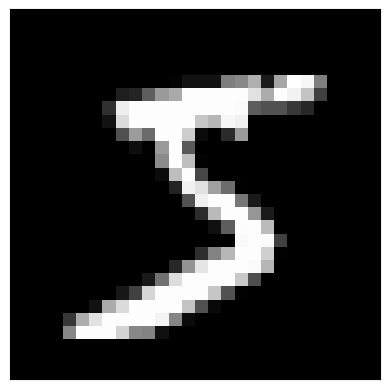

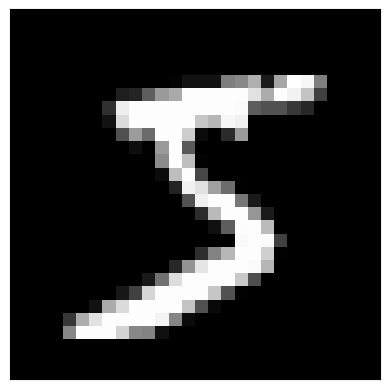

In [5]:
import matplotlib.pyplot as plt
#Display the first images in the dataset
plt.imshow(X_train[0], cmap="gray")
plt.xticks([])
plt.yticks([])
plt.grid([])
plt.show([])

In [6]:
#display the value of each pixel in the images
print("Pixel Values:")
for row in X_train[0]:
    for pixel in row:
        print("{:3}".format(pixel), end=" ")
    print()

Pixel Values:
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0 
  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0 
  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0 
  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 182 247 241   0   0   

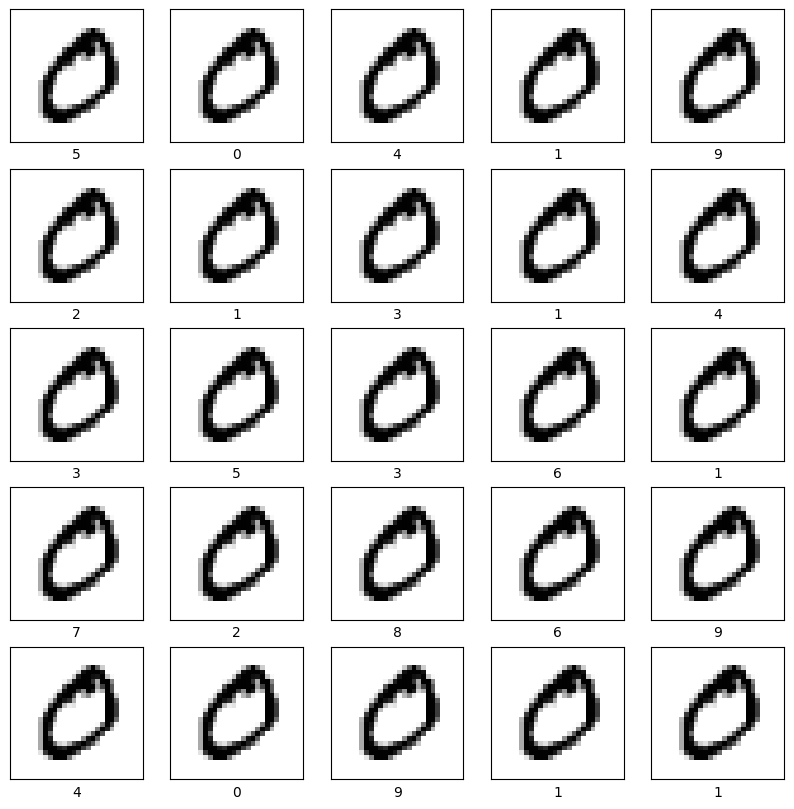

In [7]:
#display some sample images
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid([False])
    plt.imshow(X_train[1], cmap=plt.cm.binary)
    plt.xlabel(y_train[i])
plt.show()

In [8]:
# Normalize data
X_train = X_train/255.0
X_test = X_test/255.0

#reshape to add channel dimension
X_train =X_train.reshape(X_train.shape[0], 28,28,1)
X_test = X_test.reshape(X_test.shape[0],28,28,1)

#One hot encoding labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


In [9]:
#Build CNN architecture
import tensorflow as tf
from tensorflow.keras import layers

#create INPUT layers
input_layers = tf.keras.layers.Input(shape = (28,28,1)) # 28 x 28 pixel images with a single color channel


In [10]:
#CNN model building
model = tf.keras.Sequential([
    input_layers, #input layer
    layers.Conv2D(filters=10, kernel_size=(3,3), activation='relu'), #Convolutional Layer
    #Filter is the number of filters we want to apply
    #kernel is the size of window/filters moving over the image
    layers.Conv2D(filters=10, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(),#pooling layers
    layers.Conv2D(filters=10, kernel_size=(3,3), activation='relu'),
    layers.Conv2D(filters=10, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(), #Flattened Layer
    layers.Dense(10, activation='softmax') #output layer
    ])

In [11]:
#complie the model
#set the optmiizer, loss function and materics
model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
#Train the model
#fit the model to the training data
model.fit(X_train, y_train, validation_split=0.2, epochs=10, batch_size=64)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.8765 - loss: 0.3902 - val_accuracy: 0.9644 - val_loss: 0.1204
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9644 - loss: 0.1170 - val_accuracy: 0.9707 - val_loss: 0.0956
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.9731 - loss: 0.0864 - val_accuracy: 0.9737 - val_loss: 0.0830
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9768 - loss: 0.0739 - val_accuracy: 0.9776 - val_loss: 0.0733
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.9808 - loss: 0.0627 - val_accuracy: 0.9787 - val_loss: 0.0709
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.9827 - loss: 0.0559 - val_accuracy: 0.9795 - val_loss: 0.0677
Epoch 7/10
549/750 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9857 - loss: 0.0472

In [ ]:
#evaluate the model
#test the model on unseen data 
loss,accuracy = model.evaluate(X_test.y_test)
print(f"Test Accuracy:{accuracy*100:.2f}%")